<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

### 🔑 加载环境变量

参见第一个模块里的 **"Getting setup"**。

[`dotenv`](https://pypi.org/project/python-dotenv/) 会查找 `../.env`:

- ✅ **找到** → 加载里面的环境变量,**覆盖**当前 shell 中的同名变量
- ❌ **没找到** → 沿用当前 shell 中已有的变量

</div>

In [7]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

In [8]:
import os

from dotenv import load_dotenv

load_dotenv(override=True)

True

<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🤖 创建 Agent — 使用 Prebuilt 抽象

</div>

<img src="./assets/agent_header.png" width="800" style="display:block; margin-left:0;">

本课程要构建一个 [**Deep Agent**](https://blog.langchain.com/deep-agents/),底层用 LangChain 的 **预构建 agent 抽象**(可大幅简化代码)。本节先讲清楚 **预构建的 ReAct Agent**。

#### 📚 本节你会学到:
- 🧠 **什么是 ReAct Agent**
- 🛠️ 这套实现的能力,以及深入资料的去处
  - 🔧 用工具搭建 agent
  - 📊 graph、state 和 messages
  - 🎯 在工具内 **访问与修改 state**
  - 🪝 **hooks** 与结构化响应

### 🧠 什么是 ReAct Agent?

<img src="./assets/agent.png" style="float:left; max-width:300px; height:auto; margin:0 1rem 0.5rem 0;">

<div style="max-width:1250px;">

我们用 LangChain 开源的 [`create_agent`](https://docs.langchain.com/oss/python/langchain/agents) 抽象。

**ReAct Agent** = **Re**asoning + **Act**ing(推理 + 行动),把 *思维链推理 (CoT)* 与 *外部工具调用* 结合起来。该范式由论文 [*ReAct: Synergizing Reasoning and Acting in Language Models*](https://arxiv.org/abs/2210.03629) 推广。

#### 🧩 三大组件

| 组件 | 作用 |
|---|---|
| 🤖 **LLM** | 大模型,负责"想" |
| 🔧 **Tools** | 可调用工具集,负责"做" |
| 📜 **Prompt** | 系统指令,告诉它怎么想和怎么做 |

#### 🔁 工作循环

LLM 在 **循环** 中反复执行:

1. 检查上下文(含可用工具描述)
2. 判断 → **要不要调用工具?**
3. 选定工具、组装 `tool_call`
4. **工具节点**执行 → 返回观察结果 (observation)
5. LLM 根据 observation 决定下一步
6. **退出条件**:LLM 不再产生 `tool_calls` → 循环终止

> 💡 *2026 年提示*:这个 ReAct 循环已经是几乎所有 agent 框架的"事实标准"(包括 Claude Code、Cursor、Manus 等),理解它就理解了 80% 的 agent 工作原理。

</div>

<div style="clear:both;"></div>

### 🛠️ `create_agent` 的核心能力

`create_agent` 抽象自带一些功能,本课程不会全部用到,但它们解释了"为什么用它"。

- 🧠 [**Memory 集成**](https://docs.langchain.com/oss/python/concepts/memory):原生支持 *短期*(单 session)和 *长期*(跨 session 持久)记忆,让 chatbot/助手具备状态。
- 🙋 [**Human-in-the-loop**](https://docs.langchain.com/oss/python/langchain/frontend/human-in-the-loop):执行可 *无限期* 暂停等待人工反馈(不像 websocket 只能实时交互)。支持异步审批、纠错、干预。
- 📡 [**Streaming**](https://docs.langchain.com/oss/python/langchain/streaming):实时流式输出 agent 状态、模型 token、工具结果,或混合流。
- 🔭 [**LangSmith**](https://docs.langchain.com/langsmith/home):可观测性、评估、prompt 工程、调试、部署一站式。
  - 🎨 [**Studio**](https://docs.langchain.com/langsmith/studio):可视化 IDE,调试工作流。
  - 👁️ [**Observability**](https://docs.langchain.com/langsmith/observability):trace、监控、自动化。
  - 🚀 [**Deployment**](https://docs.langchain.com/langsmith/deployment):生产部署方案。

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

### ⚠️ 改名提示

`create_react_agent` 在 **1.0 版本** 中从 LangGraph 迁到了 LangChain,并改名为 **`create_agent`**(视频是录制后才改的)。

- 📒 **本课所有 notebook** 都已经更新到新接口
- 🎬 **视频** 显示的可能是旧的 `create_react_agent`,但功能一致

</div>

#### 🔧 用工具搭建 Agent

我们从一个 **简单的计算器工具** 开始,先把骨架跑通,后面再讲细节。

In [9]:
from typing import Annotated, List, Literal, Union

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command


@tool
def calculator(
    operation: Literal["add","subtract","multiply","divide"],
    a: Union[int, float],
    b: Union[int, float],
) -> Union[int, float]:
    """Define a two-input calculator tool that returns precise answers.

    Arg:
        operation (str): The operation to perform ('add', 'subtract', 'multiply', 'divide').
        a (float or int): The first number.
        b (float or int): The second number.
        
    Returns:
        result (float or int): the result of the operation
    Example
        Divide: result   = a / b
        Subtract: result = a - b
    """
    if operation == 'divide' and b == 0:
        return {"error": "Division by zero is not allowed."}

    # Perform calculation
    if operation == 'add':
        result = a + b
    elif operation == 'subtract':
        result = a - b
    elif operation == 'multiply':
        result = a * b
    elif operation == 'divide':
        result = a / b
    else: 
        result = "unknown operation"
    return result


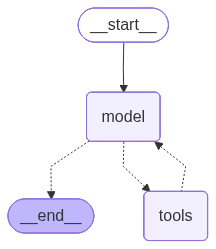

In [10]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents import create_agent 
from utils import format_messages

# Create agent using create_agent directly
SYSTEM_PROMPT = """
You are a helpful arithmetic assistant who is an expert at using a calculator. 
Return all text as plain text without Markdown math delimiters.
"""

model = init_chat_model(model="openai:gpt-4.1-mini", temperature=0.0)
tools = [calculator]

# Create agent
agent = create_agent(             # updated for 1.0
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,  # updated for 1.0
    #state_schema=AgentState,  # default
).with_config({"recursion_limit": 20})  #recursion_limit limits the number of steps the agent will run

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [11]:
# create_react_agent returns a compiled graph
type(agent)

langgraph.graph.state.CompiledStateGraph

### 📊 Graph、State 与 Messages

接下来我们运行 agent,先把 graph 看清楚。如果你想自己手搓一个简化版,可以做 [Foundation: Introduction to LangGraph, Module 1, Lesson 6, Agent](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239232-lesson-6-agent)。

#### 🏗️ 定义 Agent

你给 `create_agent` 提供 **四样东西**:
1. 🤖 **model** — 大模型
2. 🔧 **tools** — 一个或多个工具
3. 📜 **system_prompt** — 系统指令
4. 📦 **state_schema** — 默认 [`AgentState`](https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/chat_agent_executor.py#L62-L69)(本质就是一个 messages 列表)。完整调用细节见 [这里](https://reference.langchain.com/python/langchain/agents/factory/create_agent)。

底层做的事 = **定义并编译** 上图那个 LangGraph 图。

> 🔑 一个重要细节:工具节点是另一个预构建组件 [`ToolNode`](https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/tool_node.py#L239-L293) —— 它会执行 LLM 在消息里列出的 **所有** tool_calls,然后把结果返回。

#### 🚀 调用 Agent

下面就把 agent 跑起来看看输出!

In [12]:
# Example usage
result1 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 3.1 * 4.2?",
            }
        ],
    }
)

format_messages(result1["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 3.1 * 4.2?                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_Rk8TlAwnzCWIBw4A1mhIyjlg                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 multiplied by 4.2 is 13.02.                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### 🚀 调用 Agent — Sequence Diagram

时序图最能说明问题:

<img src="./assets/agent_sequence_diagram.png" style="float:left; max-width:500px; height:auto; margin:0 1rem 0.5rem 0;">

<div style="max-width:1100px;">

用户输入 `"What is 3.1 * 4.2?"`,这条消息 + system prompt + 工具描述 一起发给 LLM。

#### 🤖 LLM 决定调用 calculator,产生一个 `AIMessage`:

<pre style="background:#1e1e2e; color:#d4d4d4; padding:8px 20px; border-radius:4px; font-size:0.85em; width:97%;">
<code class="language-python">AIMessage(
    content="",
    tool_calls=[{
        "id": "call_123",
        "name": "calculator",
        "args": {"a": 3.1, "b": 4.2, "operation": "multiply"}
    }])
</code></pre>

#### 🔧 ToolNode 接收 AIMessage、执行工具、跟踪 tool_call_ids,返回 `ToolMessage`:

<pre style="background:#1e1e2e; color:#d4d4d4; padding:8px 20px; border-radius:4px; font-size:0.85em; width:97%;">
<code class="language-python">ToolMessage(
    content="13.02",            # 工具的输出
    tool_call_id="call_123")    # 必须匹配 AIMessage.tool_calls 里的 id
</code></pre>

#### ✅ LLM 看到结果 → 决定结束 → 生成最终 AIMessage 给用户

</div>

<div style="clear:both;"></div>

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

🔭 **LangSmith Trace 示例**:[查看这条 trace](https://smith.langchain.com/public/3d2062e3-8713-4510-a797-801abe44d1f7/r)

观察要点:
- 🧾 在 LLM 调用的 metadata 里能看到 **calculator 工具的描述**
- 📤 模型的响应是 **带参数的 tool call**
- 🪪 最后一次 LLM 调用里,**`tool_call_id`** 由 ToolNode 提供并与原 tool_call 匹配

</div>

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

#### 🎯 自己动手

跑一个查询,去 LangSmith 看自己的 trace,验证结果是否符合预期。**试着扩展 calculator** —— 比如加一个 `square` 操作。

</div>

In [13]:
# Try your own 
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 76 + 87?",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 76 + 87?                                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 76,                                                                                                      │
│   "b": 87                                                                                                       │
│ }                                                                                                               │
│    ID: call_joIKNXRRVn8t4vMzt1JGbwWe                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 163                                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 76 + 87 is 163.                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### 🎯 在工具内访问和修改 State

#### 📦 State 是什么

LangGraph 的一个核心特性就是 **state** —— 一个 **类型化的数据结构**,在 graph 运行期间对所有节点可见,而且可以**持久化到长期存储**。它的用途:

- 🔀 跨节点 **共享信息**
- 🐛 **调试** graph
- ⏮️ 把一个长跑的 graph **回滚** 到更早的时刻

定义 state 时,要给每个字段配一个 **reducer 函数**。reducer 描述"新值如何并入旧值",这对于 **并行节点同时写同一字段** 时尤其重要。

#### 📋 默认 `AgentState`

本例使用默认的 `AgentState`,定义在 [`langgraph.prebuilt.chat_agent_executor`](https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/chat_agent_executor.py):

```python
class AgentState(TypedDict):
    """The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    remaining_steps: NotRequired[RemainingSteps]
```

- 💬 **`messages`** — `BaseMessage` 列表(定义在 [`langchain_core`](https://github.com/langchain-ai/langchain/blob/088095b663993b1e53cf616e1ca487d1739b0d71/libs/core/langchain_core/messages/base.py)),装 LLM 收发的所有消息
  - 📝 `typing.Annotated` 允许在类型提示上挂载 metadata,语法:`Annotated[Type, metadata1, metadata2, ...]`
- ➕ **`add_messages`** reducer:把新消息 **追加** 到列表末尾
- 🔢 **`remaining_steps`** — graph 步数计数器,初始值 = `recursion_limit`,由 graph 自己维护,对用户不可见

下面快速看一下消息内容长什么样。

In [8]:
from IPython.display import JSON
from langchain_core.messages import messages_to_dict

JSON({"messages": messages_to_dict(result1["messages"])})

<IPython.core.display.JSON object>

#### 🗂️ 自定义 State

把 calculator 扩展一下,**记录所有计算过的操作**。需要做两件事:
1. 给 state 加一个 **列表** 字段
2. 写一个 **reducer 函数**,负责把新操作并入列表(并优雅处理空列表 / 空操作的情况)

In [14]:
#from langgraph.prebuilt.chat_agent_executor import AgentState
from langchain.agents import AgentState  # updated in 1.0


def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class CalcState(AgentState):
    """Graph State."""
    ops: Annotated[List[str], reduce_list]


#### 🔓 Accessing State —— 让工具拿到 state

现在我们扩展 calculator,让它能 **更新** state。这暴露出一个 **核心难题** —— 现在 state 是 calculator 工具的参数了:

<img src="./assets/state_arg_diagram.png" width="800" style="display:block; margin-left:0;">

<div class="dark-error" style="background:#2d1f1f; color:#fca5a5; padding:10px 24px; border-left:4px solid #f87171; border-radius:4px; width:97%;"><style>.dark-error strong{color:#fde047;}</style>

⚠️ **问题**:LLM 负责生成 tool call,**但它根本看不到 `state`**,所以也填不出这个参数!

</div>

💡 **解法**:在 LLM 之后 **由框架自己把 state 注入** 给工具。

<img src="./assets/inject_state_diagram.png" width="1000" style="display:block; margin-left:0;">

这通过 **`InjectedState`** 注解实现,如下示:

<pre style="background:#1e1e2e; color:#d4d4d4; padding:10px 24px; border-radius:4px; font-size:0.90em; width:97%;">
<code class="language-python">@tool
def calculator_wstate(
    operation: Literal["add","subtract","multiply","divide"],
    a: Union[int, float],
    b: Union[int, float],
    <span style="background:#3d3414; color:#fde047; padding:0 2px;">state: Annotated[CalcState, InjectedState],</span>          # ← <b>不会发给 LLM</b>
    <span style="background:#3d3414; color:#fde047; padding:0 2px;">tool_call_id: Annotated[str, InjectedToolCallId],</span>   # ← <b>不会发给 LLM</b>
) -> Union[int, float]:
</code></pre>

**机制**:
- 🚫 把 `state` 从发给 LLM 的工具描述里 **剥掉**
- 🪄 在 `ToolNode` 执行工具时,框架 **自动注入** state 和 tool_call_id

`tool_call_id` 也同理被注入(原因在下一节解释)。

#### ✏️ Updating State —— 同时更新多个字段

工具通常用一条 `ToolMessage` 把 observation 返回给 LLM(由框架自动并入 `messages`)。但如果还要更新 **其他字段**(比如 `ops` 列表),普通 return 就不够了 —— 需要用 **`Command`**:

```python
return Command(
    update={
        "ops": ops,                                                # 更新 ops 字段
        "messages": [
            ToolMessage(f"{result}", tool_call_id=tool_call_id)    # 自己造 ToolMessage
        ]
    }
)
```

> 🔑 注意:要造 `ToolMessage`,**必须有 `tool_call_id`** —— 这就是为什么前一节要把它一起注入进来。

In [15]:
@tool
def calculator_wstate(
    operation: Literal["add","subtract","multiply","divide"],
    a: Union[int, float],
    b: Union[int, float],
    state: Annotated[CalcState, InjectedState],   # not sent to LLM
    tool_call_id: Annotated[str, InjectedToolCallId] # not sent to LLM
) -> Union[int, float]:
    """Define a two-input calculator tool.

    Arg:
        operation (str): The operation to perform ('add', 'subtract', 'multiply', 'divide').
        a (float or int): The first number.
        b (float or int): The second number.
        
    Returns:
        result (float or int): the result of the operation
    Example
        Divide: result   = a / b
        Subtract: result = a - b
    """
    if operation == 'divide' and b == 0:
        return {"error": "Division by zero is not allowed."}

    # Perform calculation
    if operation == 'add':
        result = a + b
    elif operation == 'subtract':
        result = a - b
    elif operation == 'multiply':
        result = a * b
    elif operation == 'divide':
        result = a / b
    else: 
        result = "unknown operation"
    ops = [f"({operation}, {a}, {b})," ]
    return Command(
        update={
            "ops": ops,
            "messages": [
                ToolMessage(f"{result}", tool_call_id=tool_call_id)
            ],
        }
    )



In [16]:
SYSTEM_PROMPT = """
You are a helpful arithmetic assistant who is an expert at using a calculator. 
Return all text as plain text without Markdown math delimiters.
"""

model = init_chat_model(model="openai:gpt-4o-mini", temperature=0.0)
tools = [calculator_wstate]  # new tool

# Create agent
agent = create_agent(
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,
    state_schema=CalcState,  # now defining state scheme
).with_config({"recursion_limit": 20})  #recursion_limit limits the number of steps the agent will run

In [17]:
# Example usage
result2 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 3.1 * 4.2?",
            }
        ],
    }
)

format_messages(result2["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 3.1 * 4.2?                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_g83LlPtP6Rd46mY27D5f0aSb                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 multiplied by 4.2 is 13.02.                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [13]:
# notice the ops field is now in the response
JSON(result2)

<IPython.core.display.JSON object>

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

🧪 **再来一个例子**:注意下面这个例子里 **两个 tool call 一起发出**,ToolNode 会 **并行执行**。

</div>

In [18]:
# Example usage
result3 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 3.1 * 4.2 + 5.5 * 6.5?",
            }
        ],
    }
)

format_messages(result3["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 3.1 * 4.2 + 5.5 * 6.5?                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_u2Z4VYrflyqyUykFr5nrMvHT                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5.5,                                                                                                     │
│   "b": 6.5                                                                                                      │
│ }                                                                                                               │
│    ID: call_c3aJPTLTA3FtEKMMLwJF3JBo                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 35.75                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 13.020000000000001,                                                                                      │
│   "b": 35.75                                                                                                    │
│ }                                                                                                               │
│    ID: call_iiTdS9yXCADT7sr26TTXWY3F                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 48.77                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The result of 3.1 * 4.2 + 5.5 * 6.5 is 48.77.                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [15]:
JSON(result3)

<IPython.core.display.JSON object>

In [19]:
# Example usage - create your own
result4 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                # The correct answer is 414
                "content": "Please calculate ((15+23)x64+52)/6?",
            }
        ],
    }
)

format_messages(result4["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Please calculate ((15+23)x64+52)/6?                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 15,                                                                                                      │
│   "b": 23                                                                                                       │
│ }                                                                                                               │
│    ID: call_dFGuO9KJe7mswdVjmqRCq8pW                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 64,                                                                                                      │
│   "b": 1                                                                                                        │
│ }                                                                                                               │
│    ID: call_PEGsu3GGlWKlDTUilT82XF2O                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 52,                                                                                                      │
│   "b": 0                                                                                                        │
│ }                                                                                                               │
│    ID: call_KLpA4sca4oLaX5YXpGADAvWS                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "divide",                                                                                        │
│   "a": 6,                                                                                                       │
│   "b": 1                                                                                                        │
│ }                                                                                                               │
│    ID: call_NmpSaTvBTqoEpeF9DQVbnoqc                                                                            │
╰────────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 38                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 64                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 52                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 2432,                                                                                                    │
│   "b": 52                                                                                                       │
│ }                                                                                                               │
│    ID: call_XB9qP2bQpjhKipFRt0MTvNjU                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 2484                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "divide",                                                                                        │
│   "a": 2484,                                                                                                    │
│   "b": 6                                                                                                        │
│ }                                                                                                               │
│    ID: call_ZORqsrQkCZxLqksipzI8bj8A                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 414.0                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The result of the calculation ((15+23)x64+52)/6 is 414.0.                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [22]:
result4["messages"]

[HumanMessage(content='Please calculate ((15+23)x64+52)/6?', additional_kwargs={}, response_metadata={}, id='01d61d8a-912d-4173-a0fd-b516f912fc9a'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 192, 'total_tokens': 304, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6d0562729c', 'id': 'chatcmpl-DfHtBQ1hf60yi8Kv4CYCg8UmHlYQL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e24b9-4f41-7fb2-8d7b-1800eca3f37c-0', tool_calls=[{'name': 'calculator_wstate', 'args': {'operation': 'add', 'a': 15, 'b': 23}, 'id': 'call_dFGuO9KJe7mswdVjmqRCq8pW', 'type': 'tool_call'}, {'name': 'calculator_wstate', 'args': {'opera